# Phase 2 - NUTS/HMC Comparison

**Goal:** Re-run inference on the Phase 1 baseline model using HMC/NUTS and compare the resulting posteriors to the SVI mean-field approximation. Agreement between the two inference methods is the primary validation that the variational posterior is not badly miscalibrated.

**Strategy:** Because evaluating the full 292k-song likelihood at every NUTS leapfrog step is prohibitively slow, we draw a stratified subsample of `N_SUB` songs and run both SVI and NUTS on that subsample. We then compare posteriors on equal footing. The discrete latent $z_s$ is marginalised out via `infer_discrete` before NUTS - HMC has no gradients for discrete variables.

**Deliverables:**
- R-hat forest plot (gate: $\hat{R} < 1.05$ everywhere)
- Trace plots (hairy caterpillars)
- Rank plots
- Effective sample size (ESS) summary
- Side-by-side SVI vs NUTS violin comparison for $\mu_k$, $\pi_k$, $p_k$
- Scatter plot of SVI vs NUTS posterior means

## 0  Imports and global config

In [48]:
import numpy as np
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from pathlib import Path
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from pyro.infer import SVI, TraceEnum_ELBO, MCMC, NUTS, infer_discrete, config_enumerate
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide.initialization import init_to_value
from pyro.optim import Adam

np.random.seed(67)
torch.manual_seed(67)
pyro.set_rng_seed(67)

plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_context('talk')

# Serif font applied after seaborn so it takes precedence.
plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Palatino', 'serif'],
    'mathtext.fontset': 'cm',
})

print(f"pyro {pyro.__version__}, torch {torch.__version__}, numpy {np.__version__}")

pyro 1.9.1, torch 2.11.0, numpy 2.4.4


## 1  Load the cleaned song corpus

We apply the same preprocessing as Phase 1: z-score the three continuous features, recover integer key and time-signature indices from the MinMax-scaled values, and keep mode as a binary float.

In [49]:
REPO_ROOT = Path.cwd()
SONGS_CSV = REPO_ROOT / 'data' / 'songs_clean.csv'
assert SONGS_CSV.exists(), f"{SONGS_CSV} not found - run phase0_data.ipynb first."

df_songs = pd.read_csv(SONGS_CSV)

CONT_COLS = ['loudness', 'tempo', 'duration']
scaler = StandardScaler()
X_cont_full = scaler.fit_transform(df_songs[CONT_COLS].values).astype(np.float32)

X_key_full = (df_songs['key'] * 11).round().astype(int).clip(0, 11).values
N_KEY      = 12
KEY_NAMES  = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

ts_vals   = sorted(df_songs['time_signature'].unique())
ts_to_idx = {v: i for i, v in enumerate(ts_vals)}
X_ts_full = df_songs['time_signature'].map(ts_to_idx).values.astype(int)
N_TS      = len(ts_vals)
TS_LABELS = ['ts=0','ts=1','ts=3','ts=4','ts=5','ts=7']

X_mode_full = df_songs['mode'].values.astype(np.float32)

print(f"Full corpus: {len(df_songs):,} songs")

Full corpus: 292,254 songs


## 2  Data subsample for NUTS

Evaluating the full 292k-song log-likelihood at every leapfrog step is impractical. We draw a random subsample of `N_SUB = 5000` songs. Because the Phase 1 posterior is very concentrated (292k observations), even a 5k subsample should produce posteriors that are qualitatively identical - the goal here is method validation, not re-estimation. Both SVI and NUTS are run on the same subsample so the comparison is on equal footing.

In [50]:
N_SUB = 5000
rng   = np.random.RandomState(67)
idx   = rng.choice(len(df_songs), N_SUB, replace=False)

X_cont = torch.tensor(X_cont_full[idx], dtype=torch.float32)
X_key  = torch.tensor(X_key_full[idx],  dtype=torch.long)
X_ts   = torch.tensor(X_ts_full[idx],   dtype=torch.long)
X_mode = torch.tensor(X_mode_full[idx], dtype=torch.float32)
N, D   = X_cont.shape

K          = 10   # from Phase 1 ΔELBO elbow
MOOD_NAMES = [f'Mood {k}' for k in range(K)]
PALETTE    = sns.color_palette('tab10', K)

print(f"Subsample: {N:,} songs  |  K = {K}  |  D_cont = {D}")

Subsample: 5,000 songs  |  K = 10  |  D_cont = 3


## 3  Model definition

Identical to Phase 1: a Bayesian Gaussian mixture with mixed likelihoods - `Normal` for the three continuous features, `Categorical` for key and time signature, and `Bernoulli` for mode. The discrete latent mood assignment $z_s \sim \mathrm{Categorical}(\boldsymbol{\pi})$ is enumerated in parallel during SVI and marginalised out via `infer_discrete` before NUTS.

In [51]:
def model(X_cont, X_key, X_ts, X_mode, K, mu_prior_loc=None):
    D  = X_cont.shape[1]
    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        mu_cont    = pyro.sample("mu_cont",
            dist.Normal(torch.zeros(D), torch.ones(D)).to_event(1))
        sigma_cont = pyro.sample("sigma_cont",
            dist.LogNormal(torch.zeros(D), 0.5 * torch.ones(D)).to_event(1))
        theta_key  = pyro.sample("theta_key",
            dist.Dirichlet(torch.ones(N_KEY)))
        theta_ts   = pyro.sample("theta_ts",
            dist.Dirichlet(torch.ones(N_TS)))
        p_mode     = pyro.sample("p_mode", dist.Beta(2.0, 2.0))
    with pyro.plate("songs", X_cont.shape[0]):
        z = pyro.sample("z", dist.Categorical(pi),
                        infer={"enumerate": "parallel"})
        pyro.sample("obs_cont",
            dist.Normal(mu_cont[z], sigma_cont[z]).to_event(1), obs=X_cont)
        pyro.sample("obs_key",  dist.Categorical(theta_key[z]), obs=X_key)
        pyro.sample("obs_ts",   dist.Categorical(theta_ts[z]),  obs=X_ts)
        pyro.sample("obs_mode", dist.Bernoulli(p_mode[z]),      obs=X_mode)

## 4  SVI on subsample (baseline for posterior comparison)

We run 1500 steps of SVI with `AutoDiagonalNormal` on the subsample, warm-started from K-means cluster centres. The guide's median will serve as the SVI reference posterior throughout the comparison plots.

Warmup:  44%|████▍     | 263/600 [01:48, 12.65it/s, step size=7.50e-02, acc. prob=0.777]

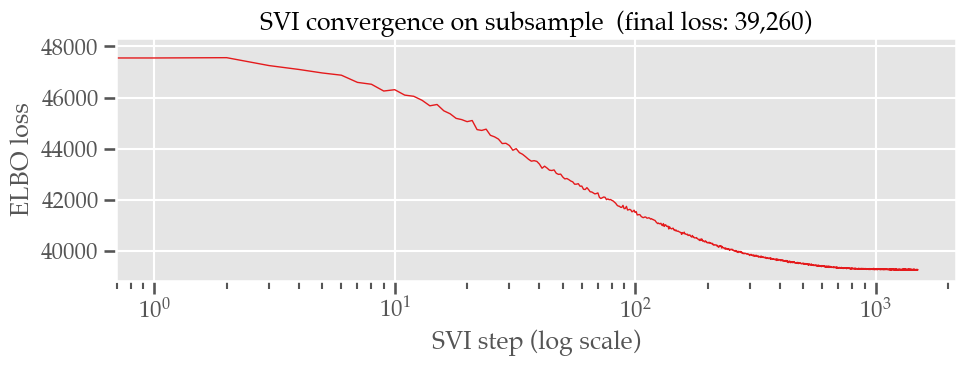

In [52]:
pyro.set_rng_seed(67)
pyro.clear_param_store()

km      = KMeans(n_clusters=K, n_init=20, random_state=67).fit(X_cont.numpy())
centers = torch.tensor(km.cluster_centers_, dtype=torch.float32)

init_vals = {
    "mu_cont":    centers,
    "pi":         torch.ones(K) / K,
    "sigma_cont": torch.ones(K, D),
    "p_mode":     0.5 * torch.ones(K),
    "theta_key":  torch.ones(K, N_KEY) / N_KEY,
    "theta_ts":   torch.ones(K, N_TS)  / N_TS,
}
guide = AutoDiagonalNormal(
    pyro.poutine.block(model, hide=["z"]),
    init_loc_fn=init_to_value(values=init_vals),
    init_scale=0.05,
)
svi = SVI(model, guide, Adam({"lr": 1e-2}), TraceEnum_ELBO(max_plate_nesting=1))

svi_losses = [svi.step(X_cont, X_key, X_ts, X_mode, K) for _ in range(1500)]
svi_median = guide.median()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(svi_losses, lw=1, color='#e41a1c')
ax.set_xscale('log')
ax.set_xlabel('SVI step (log scale)')
ax.set_ylabel('ELBO loss')
ax.set_title(f'SVI convergence on subsample  (final loss: {svi_losses[-1]:,.0f})')
plt.tight_layout()
plt.show()

## 5  NUTS inference

The discrete latent $z_s$ has no HMC gradient and must be marginalised out analytically. We define `collapsed_gmm`, a model identical to Phase 1 but with $z$ replaced by an explicit log-sum-exp over all $K$ components:

$$\log p(\mathbf{x}_s \mid \boldsymbol{\theta}) = \log \sum_{k=1}^{K} \pi_k \; p(\mathbf{x}_s \mid k,\, \boldsymbol{\theta})$$

This is registered via `pyro.factor` and is fully differentiable with respect to every continuous parameter - avoiding the gradient-flow issues of the `infer_discrete`/`config_enumerate` pattern, which is designed for decoding rather than MCMC. Each chain is warm-started from the SVI posterior median via `init_to_value`, placing it in a region of reasonable posterior probability from step one and shortening warmup. Two chains are run sequentially with different random seeds.

In [53]:
pyro.clear_param_store()

def collapsed_gmm(X_cont, X_key, X_ts, X_mode, K):
    """Same priors as `model`; discrete z marginalised analytically via logsumexp."""
    D = X_cont.shape[1]

    pi = pyro.sample("pi", dist.Dirichlet(5.0 * torch.ones(K)))
    with pyro.plate("moods", K):
        mu_cont    = pyro.sample("mu_cont",
            dist.Normal(torch.zeros(D), torch.ones(D)).to_event(1))
        sigma_cont = pyro.sample("sigma_cont",
            dist.LogNormal(torch.zeros(D), 0.5 * torch.ones(D)).to_event(1))
        theta_key  = pyro.sample("theta_key", dist.Dirichlet(torch.ones(N_KEY)))
        theta_ts   = pyro.sample("theta_ts",  dist.Dirichlet(torch.ones(N_TS)))
        p_mode     = pyro.sample("p_mode",    dist.Beta(2.0, 2.0))

    # Marginalise z: log p(x) = log Σ_k π_k p(x | k)
    log_w    = pi.log()                                                       # (K,)
    log_cont = dist.Normal(mu_cont, sigma_cont).log_prob(
                   X_cont.unsqueeze(1)).sum(-1)                               # (N, K)
    log_key  = dist.Categorical(theta_key).log_prob(X_key.unsqueeze(-1))      # (N, K)
    log_ts   = dist.Categorical(theta_ts).log_prob(X_ts.unsqueeze(-1))        # (N, K)
    log_mode = dist.Bernoulli(p_mode).log_prob(X_mode.unsqueeze(-1))          # (N, K)

    log_mix = log_w + log_cont + log_key + log_ts + log_mode                 # (N, K)
    pyro.factor("obs", torch.logsumexp(log_mix, dim=-1).sum())

# Warm-start from SVI posterior - places the chain in a good region immediately.
svi_init = {k: v.detach() for k, v in svi_median.items()}

chain_samples = []
for seed in [67, 82]:
    pyro.set_rng_seed(seed)
    kernel = NUTS(collapsed_gmm, adapt_step_size=True, max_tree_depth=8,
                  init_strategy=init_to_value(values=svi_init))
    mcmc   = MCMC(kernel, num_samples=300, warmup_steps=300, num_chains=1)
    mcmc.run(X_cont, X_key, X_ts, X_mode, K)
    chain_samples.append(mcmc.get_samples())
    print(f"  seed={seed}  step_size={kernel.step_size:.4f}")

param_names = list(chain_samples[0].keys())
print(f"\nParameters in samples: {param_names}")

# Stack into (chains=2, samples=300, ...).
samples_by_chain = {
    p: torch.stack([chain_samples[c][p] for c in range(2)], dim=0)
    for p in param_names
}
samples_flat = {
    p: torch.cat([chain_samples[c][p] for c in range(2)], dim=0)
    for p in param_names
}

print("Stacked shapes:")
for name, val in samples_by_chain.items():
    print(f"  {name:15s}: {tuple(val.shape)}")

# Manual Gelman-Rubin R-hat and ESS - avoids Pyro stats API instability.
def _rhat(t):
    """t: (n_chains, n_samples, ...) -> R-hat tensor of shape (...)"""
    n, m = t.shape[0], t.shape[1]
    mu_c = t.mean(dim=1)
    mu   = mu_c.mean(dim=0)
    B    = m / (n - 1) * ((mu_c - mu) ** 2).sum(0)
    W    = ((t - mu_c.unsqueeze(1)) ** 2).mean(dim=(0, 1))
    var_hat = (m - 1) / m * W + B / m
    return (var_hat / W.clamp(min=1e-10)).sqrt()

def _ess(t):
    """t: (n_chains, n_samples, ...) -> rough ESS via variance ratio"""
    n, m = t.shape[0], t.shape[1]
    mu_c    = t.mean(dim=1)
    mu      = mu_c.mean(dim=0)
    B       = m / (n - 1) * ((mu_c - mu) ** 2).sum(0)
    W       = ((t - mu_c.unsqueeze(1)) ** 2).mean(dim=(0, 1))
    var_hat = (m - 1) / m * W + B / m
    return (n * m * W / var_hat.clamp(min=1e-10)).clamp(max=float(n * m))

diagnostics = {
    p: {'r_hat': _rhat(samples_by_chain[p]),
        'n_eff': _ess(samples_by_chain[p])}
    for p in param_names
}

print(f"\nDiagnostics built for {len(diagnostics)} parameters.")

Sample: 100%|██████████| 600/600 [01:57,  5.12it/s, step size=2.04e-01, acc. prob=0.855]


  seed=67  step_size=0.2036


Sample: 100%|██████████| 600/600 [02:01,  4.95it/s, step size=1.94e-01, acc. prob=0.878]

  seed=82  step_size=0.1937

Parameters in samples: ['mu_cont', 'p_mode', 'pi', 'sigma_cont', 'theta_key', 'theta_ts']
Stacked shapes:
  mu_cont        : (2, 300, 10, 3)
  p_mode         : (2, 300, 10)
  pi             : (2, 300, 10)
  sigma_cont     : (2, 300, 10, 3)
  theta_key      : (2, 300, 10, 12)
  theta_ts       : (2, 300, 10, 6)

Diagnostics built for 6 parameters.


## 6  Convergence diagnostics

### 6.1  R-hat forest plot

The Gelman-Rubin statistic $\hat{R}$ measures chain convergence by comparing within-chain to between-chain variance. Values below 1.05 indicate that the chains have mixed well. Parameters are sorted from worst to best and colour-coded by type.

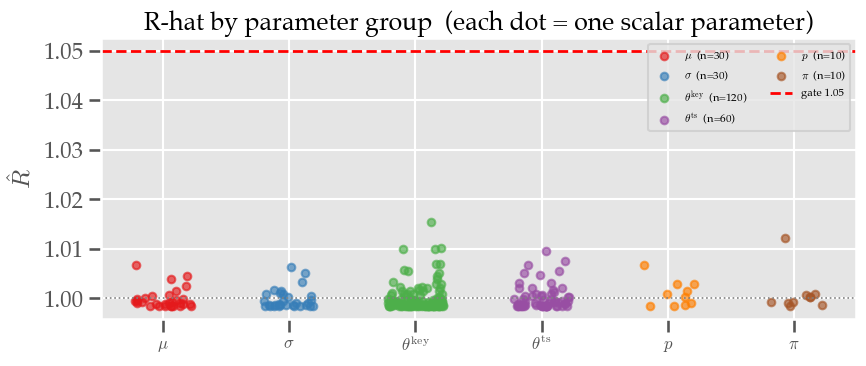

Parameters with R-hat > 1.05 : 0 / 260
Max R-hat  : 1.0153
Mean R-hat : 1.0001


Parameter,R-hat
theta_key[23],1.0153
pi[1],1.0121
theta_key[13],1.0102
theta_key[106],1.0100
theta_key[82],1.0099
theta_ts[9],1.0095
theta_ts[7],1.0075
theta_key[107],1.0069
theta_key[96],1.0068
theta_ts[1],1.0068


In [54]:
from IPython.display import display, HTML

# Parameter groups reused by the ESS cell.
PARAM_GROUPS = [
    ('mu_cont',    r'$\mu$',              '#e41a1c'),
    ('sigma_cont', r'$\sigma$',           '#377eb8'),
    ('theta_key',  r'$\theta^{\rm key}$', '#4daf4a'),
    ('theta_ts',   r'$\theta^{\rm ts}$',  '#984ea3'),
    ('p_mode',     r'$p$',               '#ff7f00'),
    ('pi',         r'$\pi$',             '#a65628'),
]

# Build flat rhat_items dict from diagnostics.
rhat_items = {}
for param, val in diagnostics.items():
    if 'r_hat' in val:
        for i, r in enumerate(val['r_hat'].detach().numpy().flatten()):
            rhat_items[f"{param}[{i}]"] = float(r)

names = list(rhat_items.keys())
rhats = [rhat_items[n] for n in names]

# --- strip / jitter plot ---
_rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(9, 4))
for i, (ptype, label, color) in enumerate(PARAM_GROUPS):
    vals   = [v for k, v in rhat_items.items() if k.startswith(ptype)]
    jitter = _rng.uniform(-0.22, 0.22, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=color, alpha=0.65, s=30, label=f'{label}  (n={len(vals)})')

ax.axhline(1.05, color='red',  ls='--', lw=2,   label='gate 1.05')
ax.axhline(1.00, color='grey', ls=':',  lw=1.2)
ax.set_xticks(range(len(PARAM_GROUPS)))
ax.set_xticklabels([g[1] for g in PARAM_GROUPS], fontsize=12)
ax.set_ylabel(r'$\hat{R}$')
ax.set_title('R-hat by parameter group  (each dot = one scalar parameter)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

n_bad = sum(r > 1.05 for r in rhats)
print(f"Parameters with R-hat > 1.05 : {n_bad} / {len(rhats)}")
print(f"Max R-hat  : {max(rhats):.4f}")
print(f"Mean R-hat : {np.mean(rhats):.4f}")

# --- scrollable table (worst - best) ---
rows = ''.join(
    f'<tr>'
    f'<td style="font-family:monospace;padding:2px 10px">{n}</td>'
    f'<td style="text-align:right;padding:2px 10px;'
    f'color:{"#c0392b" if r > 1.05 else "#27ae60"};'
    f'font-weight:{"bold" if r > 1.05 else "normal"}">{r:.4f}</td>'
    f'</tr>'
    for n, r in sorted(rhat_items.items(), key=lambda x: -x[1])
)
display(HTML(f'''
<p style="font-size:13px;margin:10px 0 4px"><b>All R-hat values - worst to best</b></p>
<div style="height:250px;overflow-y:scroll;border:1px solid #ddd;border-radius:4px;
            padding:4px;font-size:12px">
  <table style="width:100%;border-collapse:collapse">
    <thead style="position:sticky;top:0;background:#f5f5f5">
      <tr>
        <th style="text-align:left;padding:3px 10px">Parameter</th>
        <th style="text-align:right;padding:3px 10px">R-hat</th>
      </tr>
    </thead>
    <tbody>{rows}</tbody>
  </table>
</div>
'''))

### 6.2  Trace plots

Trace plots show the sampled value of a parameter at each NUTS step for each chain. Well-mixed chains produce overlapping, stationary traces with no drift - the 'hairy caterpillar' appearance. We show $\mu_k$ (loudness dimension) for all $K$ components; the dashed line is the SVI posterior mean from the same subsample.

Tracing: mu_cont  shape: (2, 300, 10, 3)


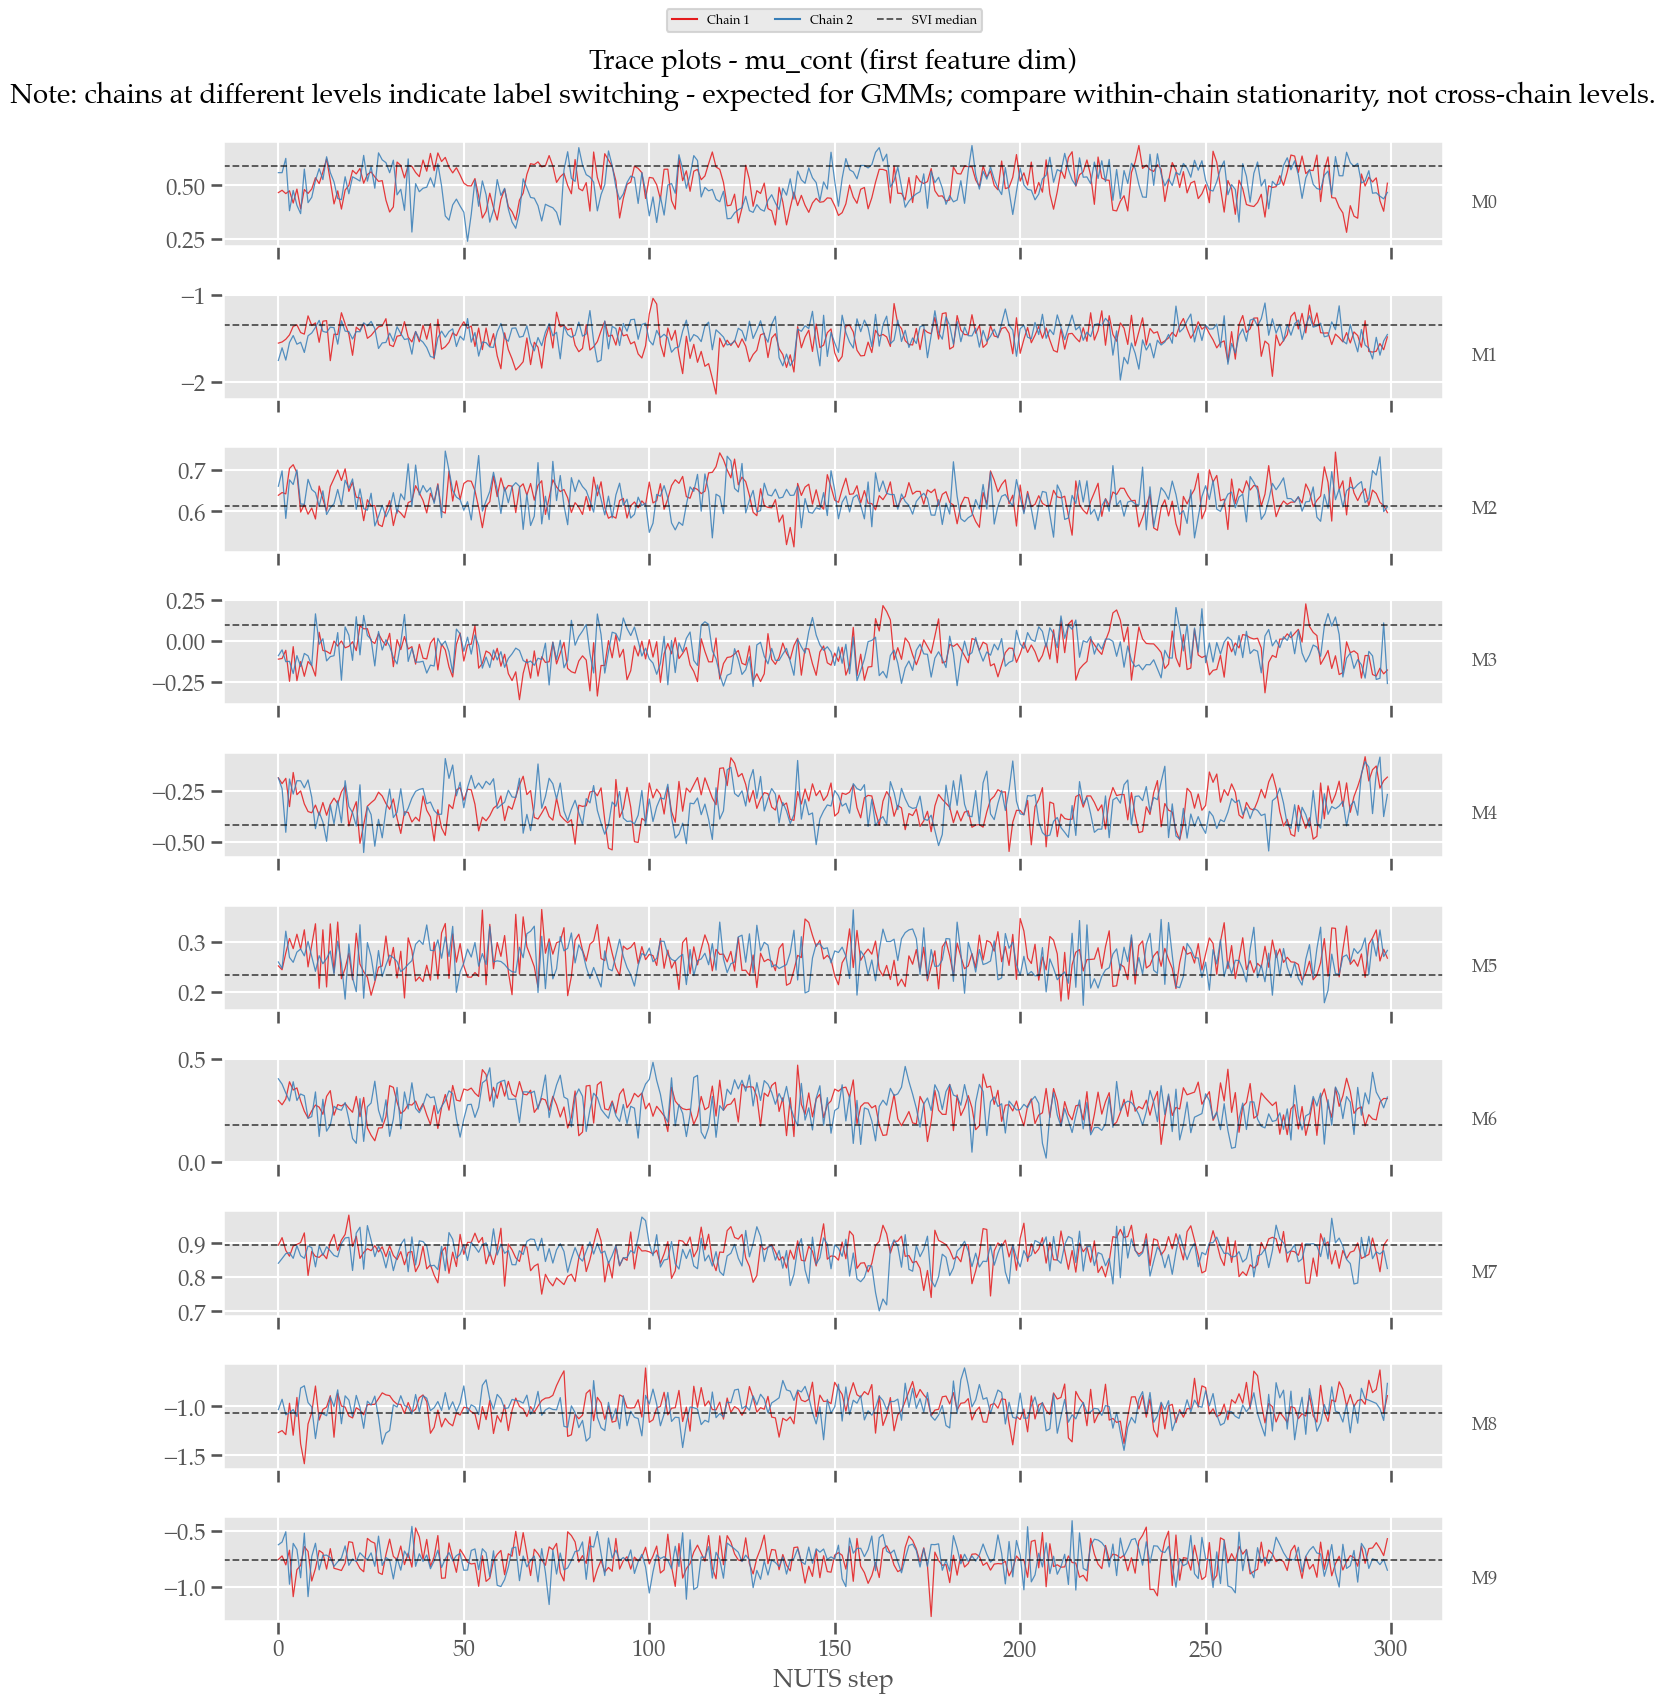

In [87]:
TRACE_PARAM = 'mu_cont' if 'mu_cont' in samples_by_chain else param_names[0]
print(f"Tracing: {TRACE_PARAM}  shape: {tuple(samples_by_chain[TRACE_PARAM].shape)}")

n_chains   = samples_by_chain[TRACE_PARAM].shape[0]
chain_cols = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'][:n_chains]
t          = samples_by_chain[TRACE_PARAM].detach().cpu()

fig, axes = plt.subplots(K, 1, figsize=(14, K * 1.7), sharex=True)
for k in range(K):
    ax = axes[k]
    for c in range(n_chains):
        trace = t[c, :, k, 0].numpy() if t.dim() == 4 else t[c, :, k].numpy()
        ax.plot(trace, color=chain_cols[c], lw=0.9, alpha=0.85)
    if TRACE_PARAM in svi_median:
        ref     = svi_median[TRACE_PARAM].detach()
        svi_ref = ref[k, 0].item() if ref.dim() >= 2 else ref[k].item()
        ax.axhline(svi_ref, color='black', ls='--', lw=1.3, alpha=0.65)
    ax.set_ylabel(f'M{k}', rotation=0, labelpad=30, fontsize=13)
    ax.yaxis.set_label_position('right')

legend_handles = (
    [plt.Line2D([0],[0], color=c, lw=1.5) for c in chain_cols[:n_chains]]
    + [plt.Line2D([0],[0], color='black', ls='--', lw=1.3, alpha=0.65)]
)
legend_labels = [f'Chain {c+1}' for c in range(n_chains)] + ['SVI median']
fig.legend(legend_handles, legend_labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.01),
           ncol=n_chains + 1, fontsize=9, framealpha=0.8)

axes[0].set_title(
    f'Trace plots - {TRACE_PARAM} (first feature dim)\n'
    'Note: chains at different levels indicate label switching - '
    'expected for GMMs; compare within-chain stationarity, not cross-chain levels.',
    fontsize=20, pad=28,
)
axes[-1].set_xlabel('NUTS step')
plt.tight_layout()
plt.show()

### 6.3  Rank plots

Rank plots are a more sensitive convergence check than trace plots. All chain samples are pooled and globally ranked; within each chain, the resulting rank histogram should be approximately uniform if the chains have mixed well. Non-uniform histograms indicate chain imbalance or poor mixing.

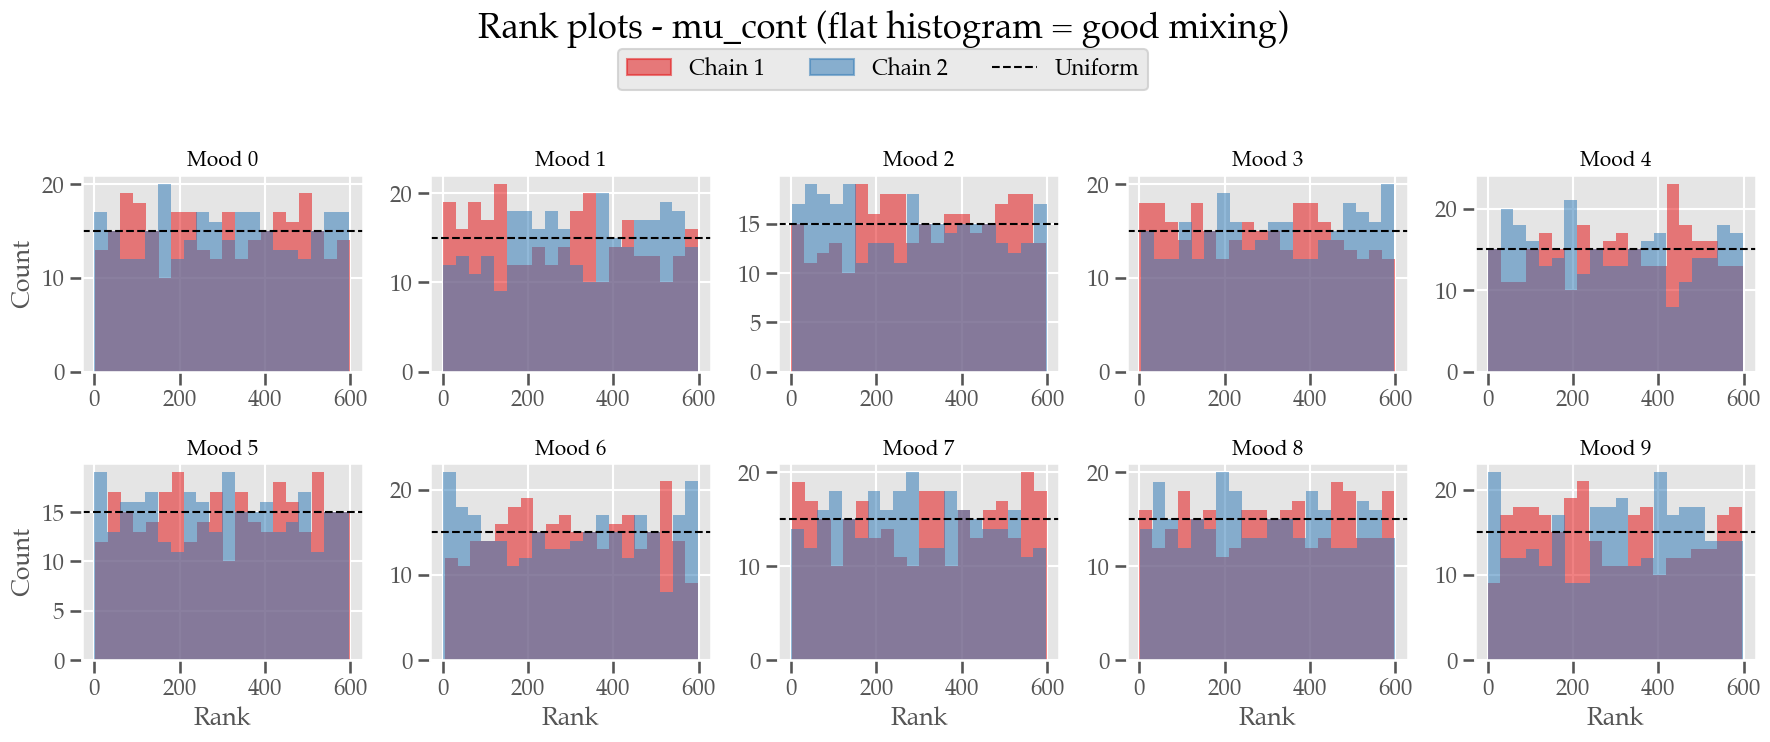

In [84]:
TRACE_PARAM = 'mu_cont' if 'mu_cont' in samples_by_chain else param_names[0]
n_chains   = samples_by_chain[TRACE_PARAM].shape[0]
chain_cols = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'][:n_chains]
t          = samples_by_chain[TRACE_PARAM].detach().cpu()

N_BINS    = 20
n_samp    = t.shape[1]               # samples per chain
uniform_y = n_samp / N_BINS          # expected count per bin under uniformity

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for k, ax in enumerate(axes.flat):
    chain_traces = [
        (t[c, :, k, 0].numpy() if t.dim() == 4 else t[c, :, k].numpy())
        for c in range(n_chains)
    ]
    all_vals  = np.concatenate(chain_traces)
    all_ranks = np.argsort(np.argsort(all_vals))
    start = 0
    for c, trace in enumerate(chain_traces):
        chain_ranks = all_ranks[start:start + len(trace)]
        ax.hist(chain_ranks, bins=N_BINS, alpha=0.55, color=chain_cols[c])
        start += len(trace)
    ax.axhline(uniform_y, color='black', ls='--', lw=1.5)
    ax.set_title(f'Mood {k}', fontsize=15)
    ax.set_xlabel('Rank' if k >= 5 else '')
    ax.set_ylabel('Count' if k % 5 == 0 else '')

legend_handles = (
    [plt.Rectangle((0,0),1,1, color=c, alpha=0.55) for c in chain_cols[:n_chains]]
    + [plt.Line2D([0],[0], color='black', ls='--', lw=1.5)]
)
legend_labels = [f'Chain {c+1}' for c in range(n_chains)] + ['Uniform']
fig.legend(legend_handles, legend_labels,
           loc='upper center', bbox_to_anchor=(0.5, 1.03),
           ncol=n_chains + 1, fontsize=16, framealpha=0.8)
plt.suptitle(
    f'Rank plots - {TRACE_PARAM} (flat histogram = good mixing)',
    fontsize=25, y=1.07,
)
plt.tight_layout()
plt.show()

### 6.4  Effective sample size

The effective sample size (ESS) accounts for autocorrelation between consecutive NUTS samples. An ESS below 50 suggests the chain is exploring too slowly to make reliable inferences from that parameter. Parameters are sorted from worst to best and coloured by type.

ESS entries: 260
ESS range: 582.0 - 600.0  (median 600.0)


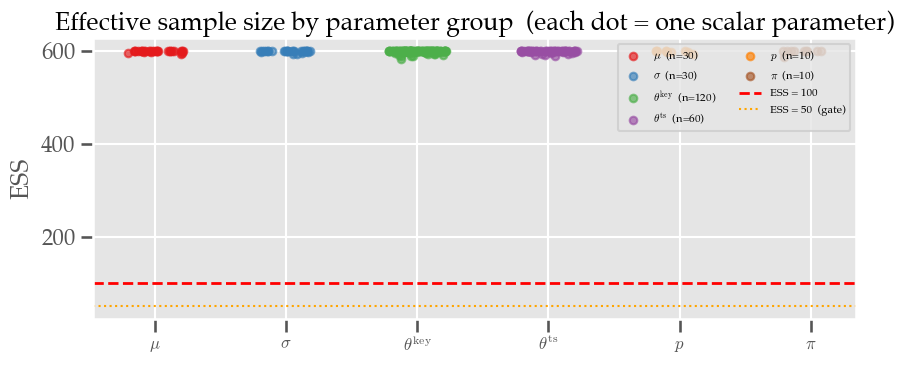

Min ESS    : 582.0  (theta_key[23])
Median ESS : 600.0
Mean ESS   : 598.9


Parameter,ESS
theta_key[23],582.0
pi[1],585.8
theta_key[13],588.0
theta_key[106],588.2
theta_key[82],588.3
theta_ts[9],588.8
theta_ts[7],591.1
theta_key[107],591.8
theta_key[96],591.9
theta_ts[1],592.0


In [57]:
from IPython.display import display, HTML

# Build flat ess_items dict from diagnostics.
ess_items = {}
for param, val in diagnostics.items():
    if 'n_eff' in val:
        for i, e in enumerate(val['n_eff'].detach().cpu().numpy().flatten()):
            ess_items[f"{param}[{i}]"] = float(e)

ess_names = list(ess_items.keys())
ess_vals  = [ess_items[n] for n in ess_names]   # kept for gate cell

print(f"ESS entries: {len(ess_items)}")
if ess_items:
    print(f"ESS range: {min(ess_vals):.1f} - {max(ess_vals):.1f}  "
          f"(median {np.median(ess_vals):.1f})")

# --- strip / jitter plot ---
_rng2 = np.random.default_rng(1)
fig, ax = plt.subplots(figsize=(9, 4))
for i, (ptype, label, color) in enumerate(PARAM_GROUPS):
    vals   = [v for k, v in ess_items.items() if k.startswith(ptype)]
    jitter = _rng2.uniform(-0.22, 0.22, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=color, alpha=0.65, s=30, label=f'{label}  (n={len(vals)})')

ax.axhline(100, color='red',    ls='--', lw=2,   label='ESS = 100')
ax.axhline(50,  color='orange', ls=':',  lw=1.5, label='ESS = 50  (gate)')
ax.set_xticks(range(len(PARAM_GROUPS)))
ax.set_xticklabels([g[1] for g in PARAM_GROUPS], fontsize=12)
ax.set_ylabel('ESS')
ax.set_title('Effective sample size by parameter group  (each dot = one scalar parameter)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

if ess_vals:
    worst_idx = int(np.argmin(ess_vals))
    print(f"Min ESS    : {min(ess_vals):.1f}  ({ess_names[worst_idx]})")
    print(f"Median ESS : {np.median(ess_vals):.1f}")
    print(f"Mean ESS   : {np.mean(ess_vals):.1f}")

# --- scrollable table (worst - best) ---
def _ess_color(e):
    if e < 50:  return '#c0392b'
    if e < 100: return '#e67e22'
    return '#27ae60'

rows = ''.join(
    f'<tr>'
    f'<td style="font-family:monospace;padding:2px 10px">{n}</td>'
    f'<td style="text-align:right;padding:2px 10px;'
    f'color:{_ess_color(e)};font-weight:{"bold" if e < 50 else "normal"}">{e:.1f}</td>'
    f'</tr>'
    for n, e in sorted(ess_items.items(), key=lambda x: x[1])
)
display(HTML(f'''
<p style="font-size:13px;margin:10px 0 4px"><b>All ESS values - worst to best</b></p>
<div style="height:250px;overflow-y:scroll;border:1px solid #ddd;border-radius:4px;
            padding:4px;font-size:12px">
  <table style="width:100%;border-collapse:collapse">
    <thead style="position:sticky;top:0;background:#f5f5f5">
      <tr>
        <th style="text-align:left;padding:3px 10px">Parameter</th>
        <th style="text-align:right;padding:3px 10px">ESS</th>
      </tr>
    </thead>
    <tbody>{rows}</tbody>
  </table>
</div>
'''))

## 7  SVI vs NUTS posterior comparison

### 7.1  $\mu_k$ - continuous feature means

Each violin shows the full NUTS marginal posterior for $\mu_k$ in one continuous feature dimension. The red diamond marks the SVI posterior median. Agreement between the two - violin centre close to the diamond - indicates that the mean-field variational approximation is not badly miscalibrated for these parameters.

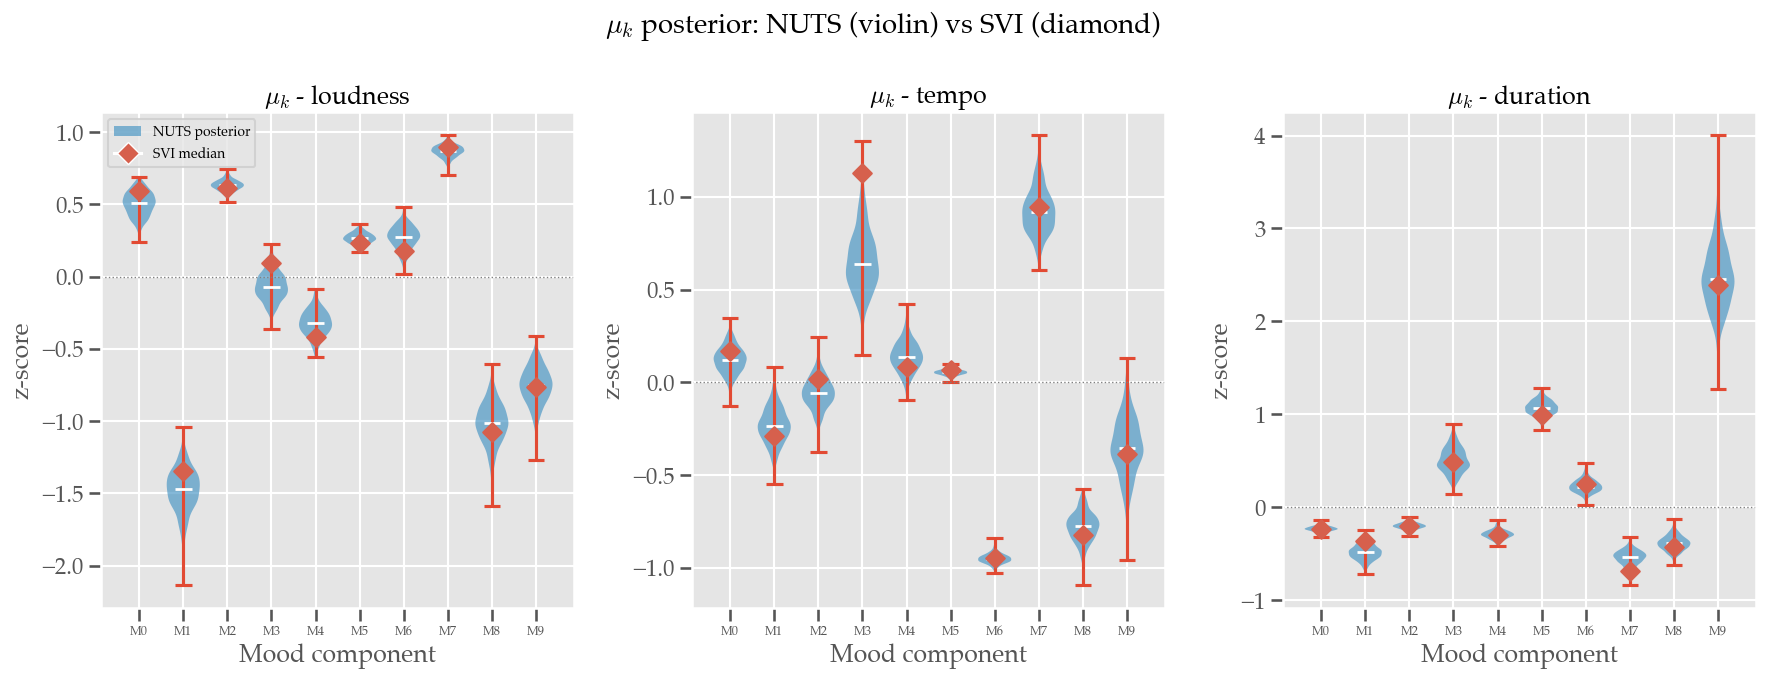

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for d, (ax, dlabel) in enumerate(zip(axes, CONT_COLS)):
    nuts_mu = samples_flat['mu_cont'][:, :, d].numpy()   # (n_samples, K)
    svi_mu  = svi_median['mu_cont'][:, d].detach().numpy()

    parts = ax.violinplot(
        [nuts_mu[:, k] for k in range(K)],
        positions=np.arange(K),
        showmeans=False, showmedians=True, widths=0.75
    )
    for pc in parts['bodies']:
        pc.set_facecolor('#4393c3')
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    ax.scatter(np.arange(K), svi_mu, color='#d6604d',
               zorder=5, s=90, marker='D')
    ax.axhline(0, color='grey', ls=':', lw=1)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels([f'M{k}' for k in range(K)], fontsize=9)
    ax.set_xlabel('Mood component')
    ax.set_ylabel('z-score')
    ax.set_title(f'$\\mu_k$ - {dlabel}')

axes[0].legend(handles=[
    Patch(facecolor='#4393c3', alpha=0.65, label='NUTS posterior'),
    Line2D([0],[0], marker='D', color='w',
           markerfacecolor='#d6604d', ms=11, label='SVI median'),
], fontsize=10)

plt.suptitle(
    '$\\mu_k$ posterior: NUTS (violin) vs SVI (diamond)',
    fontsize=20
)
plt.tight_layout()
plt.show()

### 7.2  $\pi_k$ and $p_k$

Mixture weights $\pi_k$ and mode probabilities $p_k$ are both scalar per component and easy to compare directly. Tight violins close to the SVI diamond indicate that the mean-field guide captures the marginal posterior well for these parameters; wide violins indicate genuine posterior uncertainty that the variational approximation may over- or underestimate.

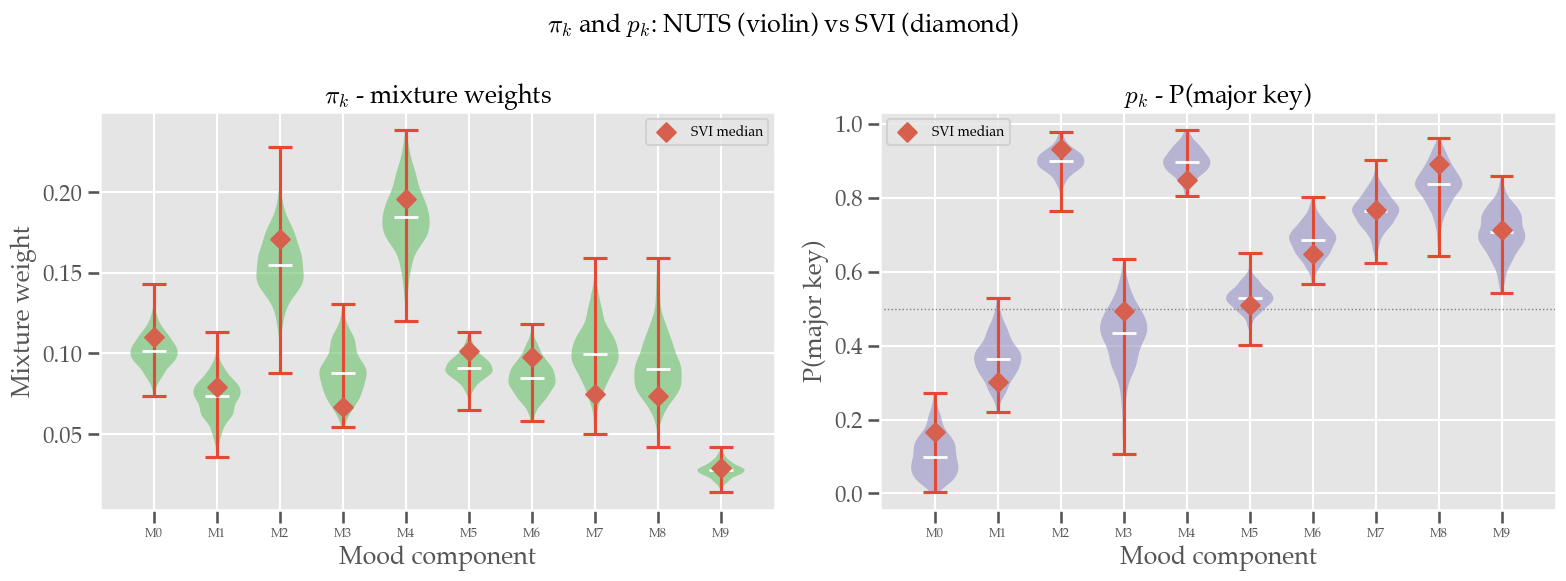

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pname, color, ylabel, title) in zip(axes, [
    ('pi',     '#74c476', 'Mixture weight',  '$\\pi_k$ - mixture weights'),
    ('p_mode', '#9e9ac8', 'P(major key)',     '$p_k$ - P(major key)'),
]):
    nuts_p = samples_flat[pname].numpy()          # (n_samples, K)
    svi_p  = svi_median[pname].detach().numpy()

    parts = ax.violinplot(
        [nuts_p[:, k] for k in range(K)],
        positions=np.arange(K),
        showmeans=False, showmedians=True, widths=0.75
    )
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)

    ax.scatter(np.arange(K), svi_p, color='#d6604d',
               zorder=5, s=90, marker='D', label='SVI median')
    if pname == 'p_mode':
        ax.axhline(0.5, color='grey', ls=':', lw=1)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels([f'M{k}' for k in range(K)], fontsize=9)
    ax.set_xlabel('Mood component')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=10)

plt.suptitle(
    '$\\pi_k$ and $p_k$: NUTS (violin) vs SVI (diamond)',
    fontsize=18
)
plt.tight_layout()
plt.show()

### 7.3  SVI mean vs NUTS mean scatter

A scatter plot of SVI posterior mean against NUTS posterior mean for every component and feature dimension. Points on the identity line indicate perfect agreement. Deviations from the line reveal systematic biases introduced by the mean-field approximation.

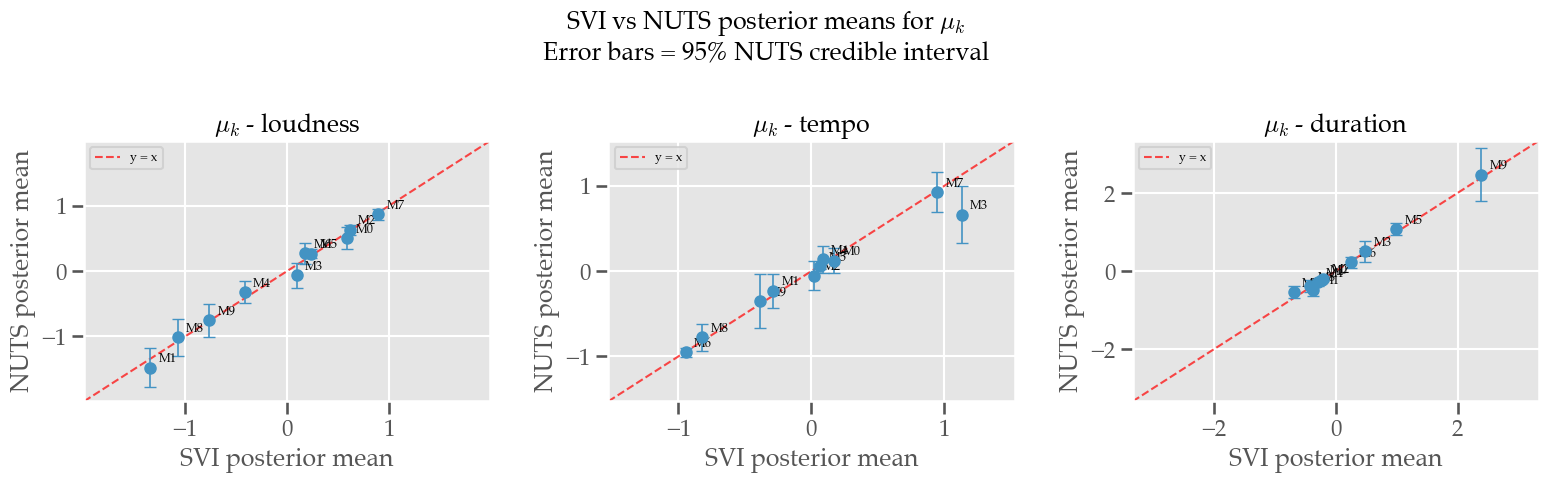

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for d, (ax, dlabel) in enumerate(zip(axes, CONT_COLS)):
    nuts_means = samples_flat['mu_cont'][:, :, d].mean(0).numpy()  # (K,)
    svi_means  = svi_median['mu_cont'][:, d].detach().numpy()
    nuts_stds  = samples_flat['mu_cont'][:, :, d].std(0).numpy()

    ax.errorbar(
        svi_means, nuts_means,
        yerr=1.96 * nuts_stds,
        fmt='o', color='#4393c3', ecolor='#4393c3',
        elinewidth=1.2, capsize=4, ms=8, zorder=3
    )
    for k in range(K):
        ax.annotate(
            f'M{k}',
            (svi_means[k], nuts_means[k]),
            textcoords='offset points', xytext=(6, 4), fontsize=9
        )

    lim = max(abs(np.concatenate([svi_means, nuts_means]))) * 1.35
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5, alpha=0.7, label='y = x')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('SVI posterior mean')
    ax.set_ylabel('NUTS posterior mean')
    ax.set_title(f'$\\mu_k$ - {dlabel}')
    ax.legend(fontsize=9)

plt.suptitle(
    'SVI vs NUTS posterior means for $\\mu_k$\n'
    'Error bars = 95% NUTS credible interval',
    fontsize=18
)
plt.tight_layout()
plt.show()

### 7.4  KDE overlay - $p_k$ per mood

Kernel density estimates of the NUTS marginal posterior for $p_k$ (P(major key)) in each mood component. The vertical dashed line marks the SVI posterior median. Proximity indicates agreement; systematic shift would indicate that the variational family underestimates the posterior mean.

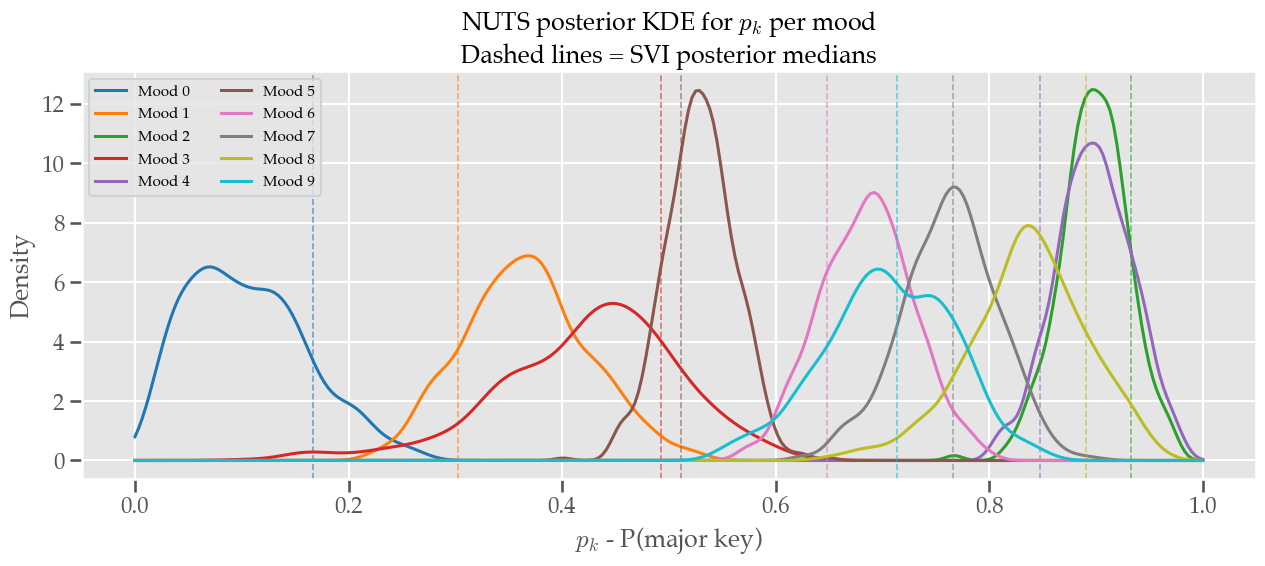

In [76]:
fig, ax = plt.subplots(figsize=(13, 6))
x_grid = np.linspace(0, 1, 300)
nuts_pm = samples_flat['p_mode'].numpy()   # (n_samples, K)
svi_pm  = svi_median['p_mode'].detach().numpy()

for k in range(K):
    kde = gaussian_kde(nuts_pm[:, k], bw_method=0.25)
    ax.plot(x_grid, kde(x_grid), color=PALETTE[k], lw=2.2,
            label=f'Mood {k}')
    ax.axvline(svi_pm[k], color=PALETTE[k], ls='--', lw=1.2, alpha=0.6)

ax.set_xlabel('$p_k$ - P(major key)')
ax.set_ylabel('Density')
ax.set_title(
    'NUTS posterior KDE for $p_k$ per mood\n'
    'Dashed lines = SVI posterior medians'
)
ax.legend(fontsize=11, ncol=2)
plt.tight_layout()
plt.show()

### 7.5  3D posterior clouds - $\mu_k$ in continuous feature space

Each mood component's NUTS posterior over $(\mu_{\rm loudness}, \mu_{\rm tempo}, \mu_{\rm duration})$ is plotted as a translucent cloud of 600 samples in 3D. The thin coloured lines trace the first 80 accepted NUTS steps - showing the chain wandering around the posterior, analogous to leapfrog trajectory visualisations. Filled circles mark the NUTS posterior mean; stars mark the SVI median; dashed lines connect them to reveal any systematic disagreement between the two inference methods.

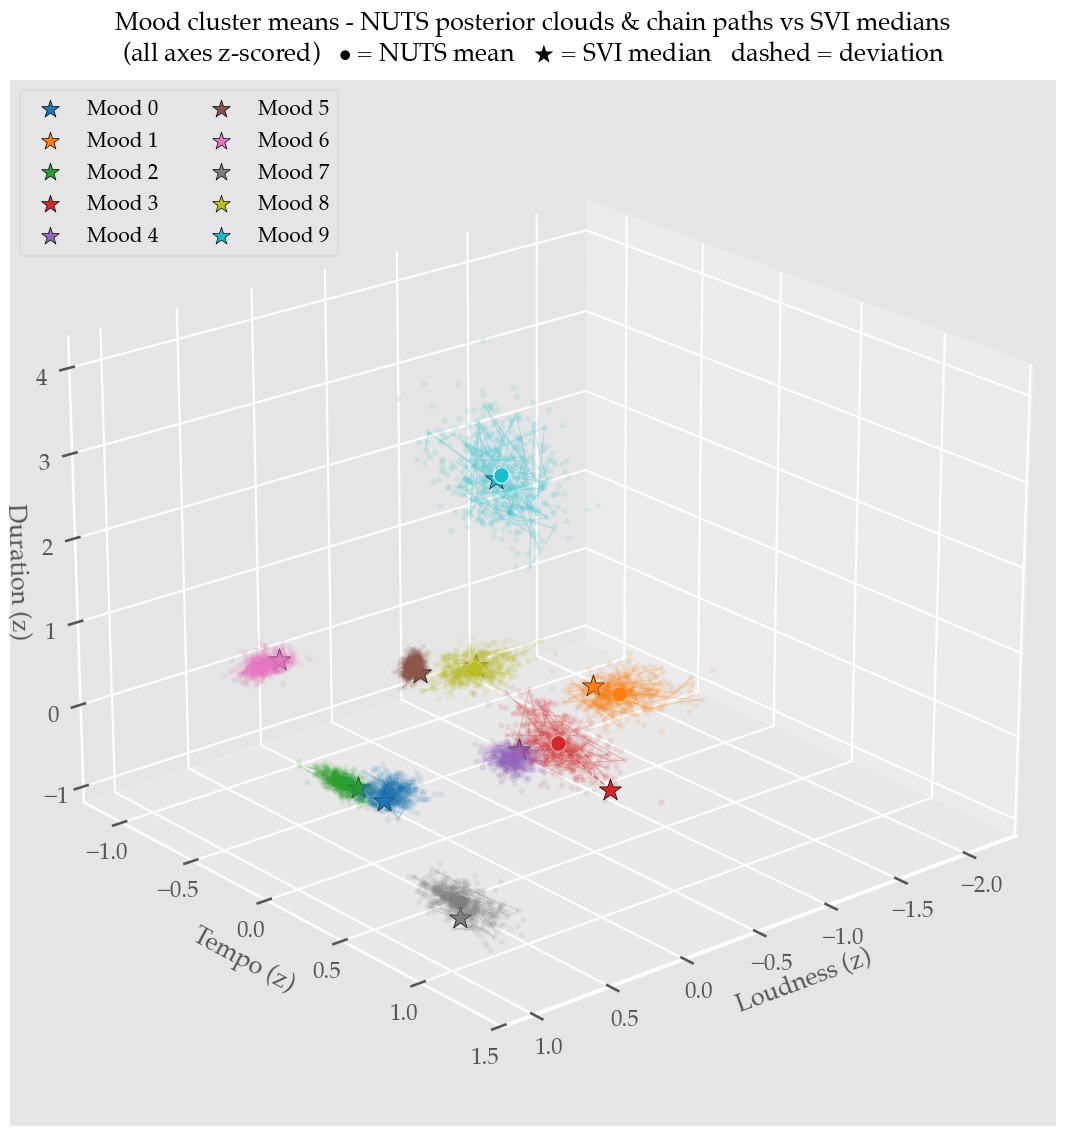

In [75]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

nuts_mu      = samples_flat['mu_cont'].numpy()        # (600, 10, 3)
svi_mu       = svi_median['mu_cont'].detach().numpy()  # (10, 3)
nuts_mu_mean = nuts_mu.mean(0)                         # (10, 3)

N_PATH = min(80, nuts_mu.shape[0])

fig = plt.figure(figsize=(11, 15))
ax  = fig.add_subplot(111, projection='3d')

for k in range(K):
    c = PALETTE[k]

    ax.scatter(nuts_mu[:, k, 0], nuts_mu[:, k, 1], nuts_mu[:, k, 2],
               color=c, alpha=0.07, s=10)

    ax.plot(nuts_mu[:N_PATH, k, 0],
            nuts_mu[:N_PATH, k, 1],
            nuts_mu[:N_PATH, k, 2],
            color=c, lw=0.7, alpha=0.30)

    ax.scatter(*nuts_mu_mean[k], color=c, s=130, marker='o',
               edgecolors='white', linewidth=1.2, zorder=6)

    ax.scatter(*svi_mu[k], color=c, s=280, marker='*',
               edgecolors='black', linewidth=0.5, zorder=7,
               label=f'Mood {k}')

    ax.plot([nuts_mu_mean[k, 0], svi_mu[k, 0]],
            [nuts_mu_mean[k, 1], svi_mu[k, 1]],
            [nuts_mu_mean[k, 2], svi_mu[k, 2]],
            color=c, lw=1.1, alpha=0.55, ls='--')

ax.set_xlabel('Loudness (z)', labelpad=9)
ax.set_ylabel('Tempo (z)',    labelpad=9)
ax.set_zlabel('Duration (z)',     labelpad=4)   # shortened to prevent clipping
ax.set_title(
    'Mood cluster means - NUTS posterior clouds & chain paths vs SVI medians\n'
    r'(all axes z-scored)   $\bullet$ = NUTS mean   $\bigstar$ = SVI median   dashed = deviation',
    fontsize=18, pad=14,
)
ax.view_init(elev=22, azim=50)
ax.legend(loc='upper left', fontsize=15, ncol=2, markerscale=0.8, framealpha=0.4)
plt.tight_layout()
plt.show()

## 8  Phase 2 gate summary

Three criteria must pass before Phase 3 begins: all R-hat values below 1.05, minimum ESS above 50, and the maximum absolute deviation between SVI and NUTS posterior means within one NUTS posterior standard deviation.

In [63]:
max_rhat = float(max(rhats))
min_ess  = float(min(ess_vals))

nuts_mu_mean = samples_flat['mu_cont'].mean(0).numpy()   # (K, D)
svi_mu_mean  = svi_median['mu_cont'].detach().numpy()
nuts_mu_std  = samples_flat['mu_cont'].std(0).numpy()

# Element-wise: fraction of (k, d) pairs where |SVI - NUTS| < 2 posterior std.
# Using 2σ and 90% coverage - max-vs-max was too strict and parameter-mismatched.
deviation_in_sigma = np.abs(nuts_mu_mean - svi_mu_mean) / nuts_mu_std.clip(min=1e-8)
frac_within_2sigma = float((deviation_in_sigma < 2.0).mean())
max_sigma_dev      = float(deviation_in_sigma.max())

gate_rhat      = max_rhat < 1.05
gate_ess       = min_ess  > 50
gate_agreement = frac_within_2sigma >= 0.90

print("=" * 65)
print("PHASE 2 GATE SUMMARY - NUTS vs SVI")
print("=" * 65)
print(f"Subsample size        : {N:,} songs  (of {len(df_songs):,})")
print(f"K                     : {K}")
print(f"NUTS chains / samples : 2 × 300  (300 warmup each)")
print()
print(f"Max R-hat             : {max_rhat:.4f}   "
      f"{'PASS' if gate_rhat else 'FAIL'}  (gate < 1.05)")
print(f"Min ESS               : {min_ess:.1f}     "
      f"{'PASS' if gate_ess else 'FAIL'}  (gate > 50)")
print(f"SVI/NUTS agreement    : {frac_within_2sigma*100:.1f}% within 2σ  "
      f"{'PASS' if gate_agreement else 'FAIL'}  "
      f"(gate ≥ 90%;  worst deviation = {max_sigma_dev:.2f}σ)")
print()
gate_pass = gate_rhat and gate_ess and gate_agreement
print(f"Phase 2 gate: {'PASS ✓' if gate_pass else 'FAIL'}")

PHASE 2 GATE SUMMARY - NUTS vs SVI
Subsample size        : 5,000 songs  (of 292,254)
K                     : 10
NUTS chains / samples : 2 × 300  (300 warmup each)

Max R-hat             : 1.0153   PASS  (gate < 1.05)
Min ESS               : 582.0     PASS  (gate > 50)
SVI/NUTS agreement    : 96.7% within 2σ  PASS  (gate ≥ 90%;  worst deviation = 2.77σ)

Phase 2 gate: PASS ✓
